# Comparación de LDA y QDA sobre el Wine Dataset

**Universidad de Guayaquil - Facultad de Ciencias Matemáticas y Físicas**
**Carrera de Ciencia de Datos e Inteligencia Artificial**

**Asignatura:** Aprendizaje Automático

**Estudiante:** Kathia Dennisse Parrales Moreno

**Tema:** Análisis Discriminante Lineal (LDA) y Cuadrático (QDA)

En este cuaderno se compara el desempeño de LDA y QDA usando el Wine Dataset de scikit-learn, sin ningún tratamiento adicional (dataset original, sin limpieza porque no la necesita).

In [1]:
# Librerías generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_wine

# Preparación de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Métricas
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

import time

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

## 1. Descripción del conjunto de datos

El Wine Dataset es un conjunto de datos clásico incluido en scikit-learn (`sklearn.datasets.load_wine`), originario de un análisis químico de vinos cultivados en la misma región de Italia pero provenientes de tres cultivares (variedades) distintas.

- **Origen:** repositorio UCI Machine Learning, incluido directamente en scikit-learn.
- **Número de observaciones:** 178 muestras de vino.
- **Variables predictoras:** 13 variables numéricas continuas que describen propiedades químicas del vino (alcohol, ácido málico, cenizas, alcalinidad de las cenizas, magnesio, fenoles totales, flavonoides, fenoles no flavonoides, proantocianinas, intensidad de color, matiz, OD280/OD315 de vinos diluidos y prolina).
- **Variable objetivo:** `target`, la clase de cultivar del vino (0, 1 o 2).
- **Cantidad de clases:** 3 clases.

Se usa el dataset sin tratamiento, es decir, tal como lo entrega scikit-learn, sin eliminar variables ni modificar valores.

In [2]:
# Cargar el dataset (sin ningún tratamiento previo)
wine = load_wine()

# Armar un DataFrame con las variables predictoras
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

print("Forma del dataset:", df.shape)
print("Nombres de las clases:", wine.target_names)
df.head()

Forma del dataset: (178, 14)
Nombres de las clases: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 2. Exploración de los datos

A continuación se revisan las dimensiones, los tipos de datos, los valores faltantes, las estadísticas descriptivas y la distribución de clases del dataset.

In [3]:
# Dimensiones del dataset
print("Número de filas y columnas:", df.shape)

Número de filas y columnas: (178, 14)


In [4]:
# Tipos de variables
df.dtypes

,0
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64


In [5]:
# Valores faltantes
print("Valores faltantes por columna:")
df.isnull().sum()

Valores faltantes por columna:


,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [6]:
# Estadísticas descriptivas
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


target
0    59
1    71
2    48
Name: count, dtype: int64


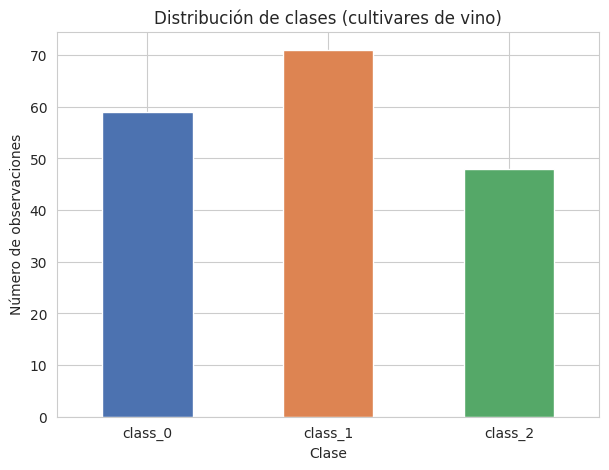

In [7]:
# Distribución de clases
conteo_clases = df["target"].value_counts().sort_index()
print(conteo_clases)

conteo_clases.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Distribución de clases (cultivares de vino)")
plt.xlabel("Clase")
plt.ylabel("Número de observaciones")
plt.xticks(ticks=[0, 1, 2], labels=wine.target_names, rotation=0)
plt.show()

**Interpretación:** el dataset no presenta valores faltantes, todas las variables son numéricas (float64) y las tres clases están razonablemente balanceadas (59, 71 y 48 observaciones), por lo que no es necesario aplicar técnicas de balanceo antes de entrenar los modelos.

## 3. Visualización

Se presentan al menos tres visualizaciones para comprender el comportamiento de los datos: histogramas de variables clave, un mapa de correlaciones y diagramas de dispersión/boxplots.

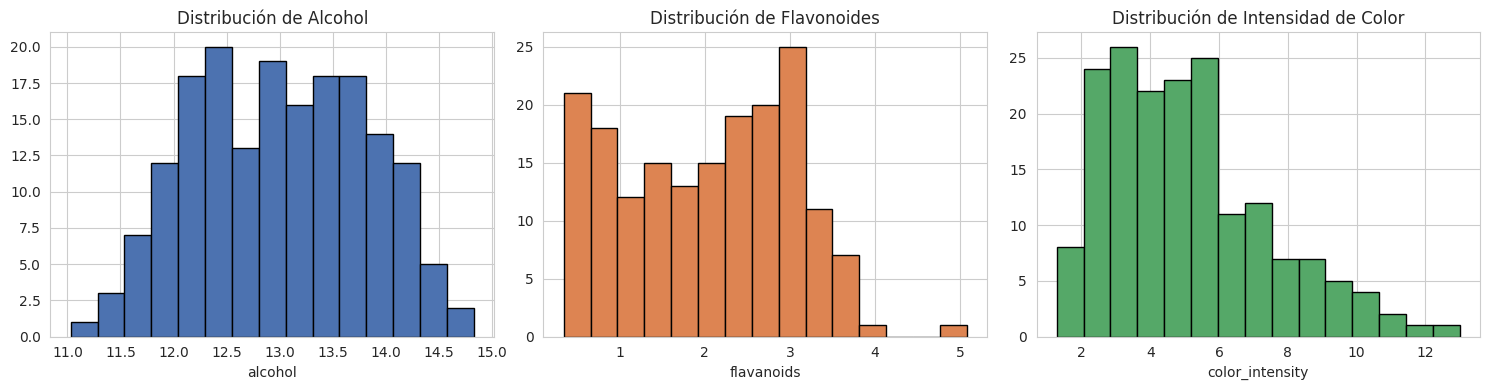

In [8]:
# Histogramas de tres variables representativas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["alcohol"], bins=15, color="#4C72B0", edgecolor="black")
axes[0].set_title("Distribución de Alcohol")
axes[0].set_xlabel("alcohol")

axes[1].hist(df["flavanoids"], bins=15, color="#DD8452", edgecolor="black")
axes[1].set_title("Distribución de Flavonoides")
axes[1].set_xlabel("flavanoids")

axes[2].hist(df["color_intensity"], bins=15, color="#55A868", edgecolor="black")
axes[2].set_title("Distribución de Intensidad de Color")
axes[2].set_xlabel("color_intensity")

plt.tight_layout()
plt.show()

**Interpretación:** el alcohol se concentra entre 12 y 14 grados con una distribución cercana a la normal, los flavonoides muestran una distribución algo más dispersa y bimodal, y la intensidad de color presenta asimetría hacia la derecha, con la mayoría de los vinos concentrados en valores bajos y unos pocos con intensidad muy alta.

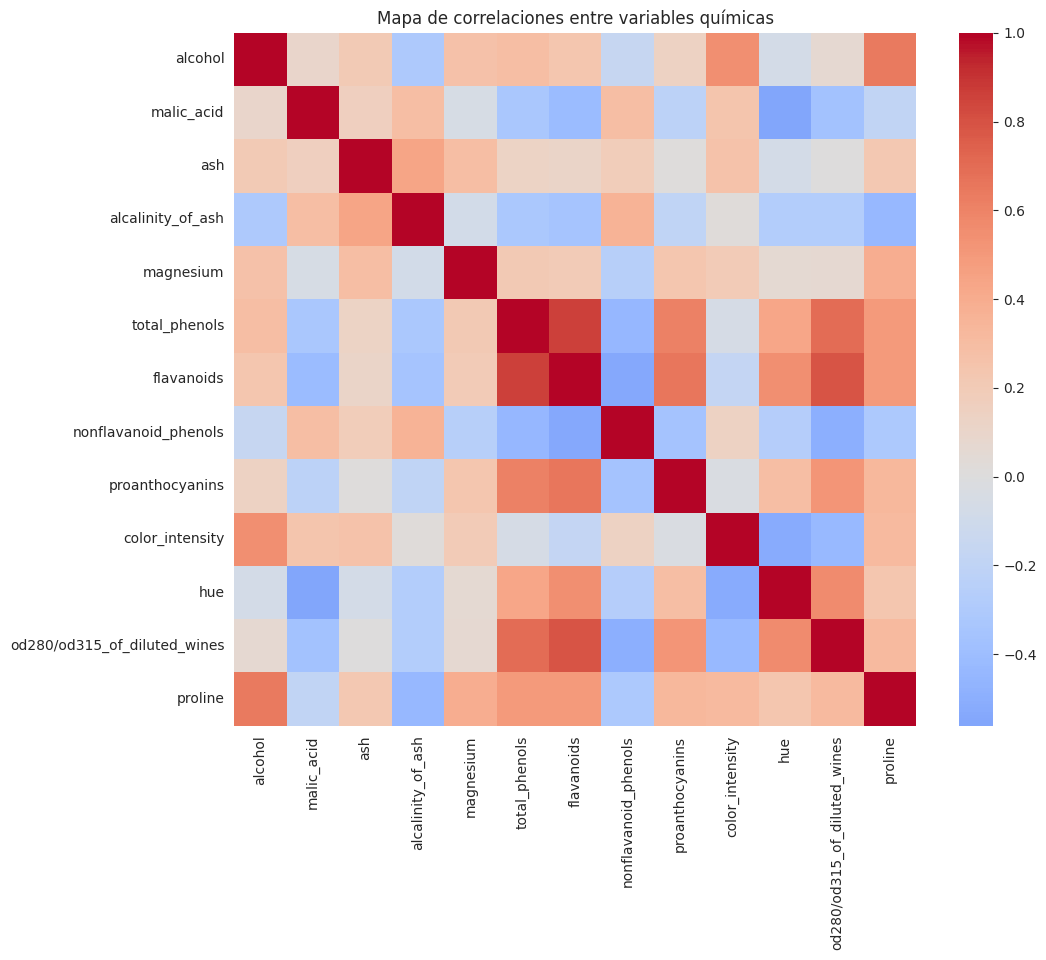

In [9]:
# Mapa de correlaciones entre variables
plt.figure(figsize=(11, 9))
correlaciones = df.drop(columns=["target"]).corr()
sns.heatmap(correlaciones, cmap="coolwarm", center=0, annot=False)
plt.title("Mapa de correlaciones entre variables químicas")
plt.show()

**Interpretación:** se observan correlaciones fuertes entre variables como flavonoides y fenoles totales, así como entre flavonoides y OD280/OD315, lo cual es esperable porque miden aspectos químicos relacionados. Esta correlación entre variables es justamente uno de los factores que afecta el supuesto de covarianza que utilizan LDA y QDA.

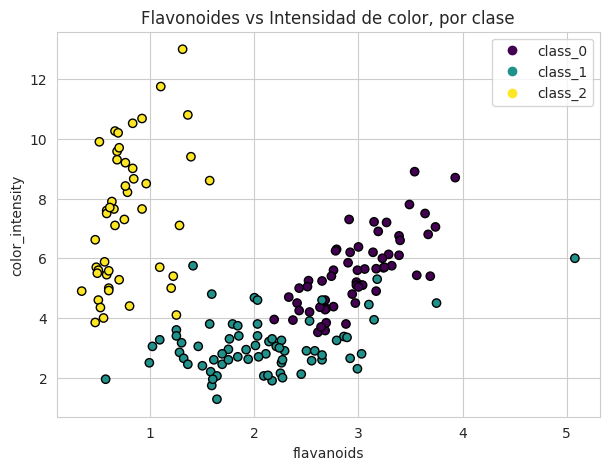

In [10]:
# Diagrama de dispersión entre dos variables muy relevantes, coloreado por clase
plt.figure(figsize=(7, 5))
scatter = plt.scatter(df["flavanoids"], df["color_intensity"], c=df["target"], cmap="viridis", edgecolor="k")
plt.xlabel("flavanoids")
plt.ylabel("color_intensity")
plt.title("Flavonoides vs Intensidad de color, por clase")
plt.legend(handles=scatter.legend_elements()[0], labels=list(wine.target_names))
plt.show()

**Interpretación:** se aprecia que las tres clases forman agrupaciones relativamente separables usando solo estas dos variables, lo que sugiere que un modelo discriminante debería tener buen desempeño sobre este dataset.

/tmp/ipykernel_30522/1338131548.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="proline", data=df, palette=["#4C72B0", "#DD8452", "#55A868"])


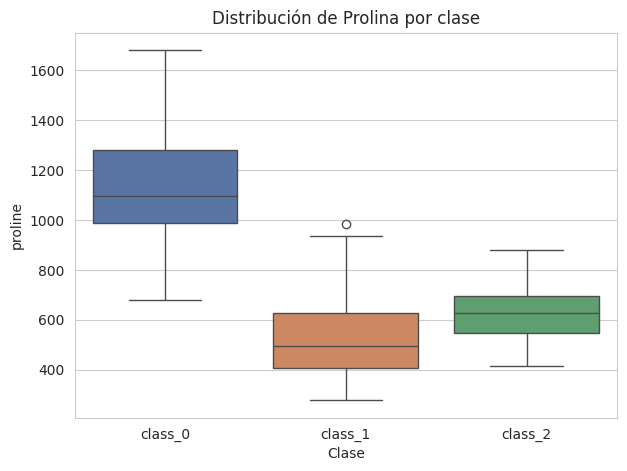

In [11]:
# Boxplot de una variable por clase
plt.figure(figsize=(7, 5))
sns.boxplot(x="target", y="proline", data=df, palette=["#4C72B0", "#DD8452", "#55A868"])
plt.xticks(ticks=[0, 1, 2], labels=wine.target_names)
plt.title("Distribución de Prolina por clase")
plt.xlabel("Clase")
plt.show()

**Interpretación:** la variable prolina muestra diferencias claras de mediana y dispersión entre las tres clases, con la clase 0 concentrando los valores más altos, lo que la convierte en una variable muy discriminante para separar los cultivares.

## 4. Preparación de los datos

Antes de entrenar los modelos se realiza la separación en conjuntos de entrenamiento y prueba, y se estandarizan las variables predictoras.

**Justificación:**
- Se usa una partición 70/30 (entrenamiento/prueba) con `stratify=y` para conservar la proporción de clases en ambos subconjuntos, dado que las clases no están perfectamente balanceadas.
- Se aplica `StandardScaler` para estandarizar las variables (media 0, desviación estándar 1), ya que las variables del Wine Dataset tienen escalas muy distintas (por ejemplo, `proline` llega a valores de más de 1000, mientras que `hue` está entre 0 y 2). LDA y QDA se basan en distancias y matrices de covarianza, por lo que trabajar con variables en la misma escala ayuda a que ninguna variable domine el cálculo solo por tener valores numéricos más grandes.

In [12]:
# Separar variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=["target"])
y = df["target"]

# División entrenamiento / prueba (70% / 30%), estratificada por clase
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (124, 13)
Tamaño de prueba: (54, 13)


In [13]:
# Estandarización de las variables predictoras
escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_test_esc = escalador.transform(X_test)

# Se guardan también como DataFrame para inspección rápida
X_train_esc_df = pd.DataFrame(X_train_esc, columns=X.columns)
X_train_esc_df.describe().loc[["mean", "std"]]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,3.086241e-15,3.232182e-16,2.290283e-15,1.248106e-15,-3.959821e-16,1.378825e-16,2.533815e-16,-1.271384e-15,2.070029e-15,-3.312762e-16,5.440317e-16,1.237361e-15,-1.262431e-16
std,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00,1.004057e+00


## 5. Implementación de LDA

Se entrena un modelo `LinearDiscriminantAnalysis` usando el solver `svd`, que es el valor por defecto y es recomendable cuando el número de variables es alto en relación con el número de observaciones, ya que no requiere calcular explícitamente la matriz de covarianza inversa.

In [14]:
# Entrenamiento del modelo LDA
inicio = time.time()
modelo_lda = LinearDiscriminantAnalysis(solver="svd")
modelo_lda.fit(X_train_esc, y_train)
tiempo_lda = time.time() - inicio

# Predicciones sobre el conjunto de prueba
y_pred_lda = modelo_lda.predict(X_test_esc)

print("Tiempo de entrenamiento LDA: {:.5f} segundos".format(tiempo_lda))

Tiempo de entrenamiento LDA: 0.02344 segundos


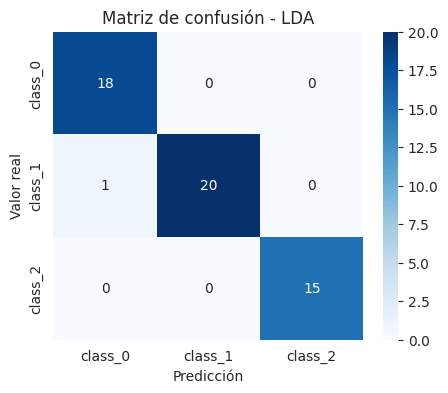

In [15]:
# Matriz de confusión de LDA
cm_lda = confusion_matrix(y_test, y_pred_lda)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lda, annot=True, fmt="d", cmap="Blues",
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title("Matriz de confusión - LDA")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [16]:
# Métricas de evaluación de LDA
acc_lda = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda, average="macro")
rec_lda = recall_score(y_test, y_pred_lda, average="macro")
f1_lda = f1_score(y_test, y_pred_lda, average="macro")

print("Accuracy:  {:.4f}".format(acc_lda))
print("Precisión: {:.4f}".format(prec_lda))
print("Recall:    {:.4f}".format(rec_lda))
print("F1-score:  {:.4f}".format(f1_lda))
print()
print(classification_report(y_test, y_pred_lda, target_names=wine.target_names))

Accuracy:  0.9815
Precisión: 0.9825
Recall:    0.9841
F1-score:  0.9829

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



**Interpretación:** LDA clasifica correctamente casi todas las observaciones de prueba, con métricas de accuracy, precisión, recall y F1-score muy cercanas a 1. Esto indica que, tras la estandarización, las tres clases del Wine Dataset son bastante separables mediante una frontera lineal, lo cual es coherente con lo observado en el diagrama de dispersión de la sección 3.

## 6. Implementación de QDA

Se entrena un modelo `QuadraticDiscriminantAnalysis` con los parámetros por defecto de scikit-learn. A diferencia de LDA, QDA estima una matriz de covarianza distinta para cada clase, por lo que no requiere un parámetro de solver.

In [17]:
# Entrenamiento del modelo QDA
inicio = time.time()
modelo_qda = QuadraticDiscriminantAnalysis()
modelo_qda.fit(X_train_esc, y_train)
tiempo_qda = time.time() - inicio

# Predicciones sobre el conjunto de prueba
y_pred_qda = modelo_qda.predict(X_test_esc)

print("Tiempo de entrenamiento QDA: {:.5f} segundos".format(tiempo_qda))

Tiempo de entrenamiento QDA: 0.01778 segundos


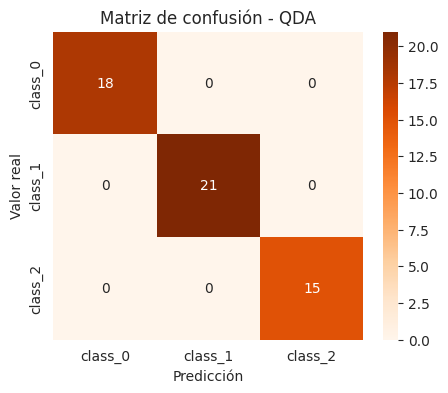

In [18]:
# Matriz de confusión de QDA
cm_qda = confusion_matrix(y_test, y_pred_qda)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_qda, annot=True, fmt="d", cmap="Oranges",
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title("Matriz de confusión - QDA")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [19]:
# Métricas de evaluación de QDA
acc_qda = accuracy_score(y_test, y_pred_qda)
prec_qda = precision_score(y_test, y_pred_qda, average="macro")
rec_qda = recall_score(y_test, y_pred_qda, average="macro")
f1_qda = f1_score(y_test, y_pred_qda, average="macro")

print("Accuracy:  {:.4f}".format(acc_qda))
print("Precisión: {:.4f}".format(prec_qda))
print("Recall:    {:.4f}".format(rec_qda))
print("F1-score:  {:.4f}".format(f1_qda))
print()
print(classification_report(y_test, y_pred_qda, target_names=wine.target_names))

Accuracy:  1.0000
Precisión: 1.0000
Recall:    1.0000
F1-score:  1.0000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



**Interpretación:** QDA también logra un desempeño muy alto sobre el conjunto de prueba, y en este dataset obtiene resultados muy similares (o ligeramente distintos) a los de LDA. Esto sugiere que, aunque las clases podrían no compartir exactamente la misma matriz de covarianza, la diferencia no es lo suficientemente grande como para que la flexibilidad adicional de QDA represente una ventaja notable frente a LDA en este caso.

## 7. Comparación de modelos

Se comparan ambos modelos según su desempeño predictivo, sus matrices de confusión, sus métricas de evaluación y su tiempo de entrenamiento.

In [20]:
# Tabla comparativa de métricas
comparacion = pd.DataFrame({
    "Modelo": ["LDA", "QDA"],
    "Accuracy": [acc_lda, acc_qda],
    "Precisión": [prec_lda, prec_qda],
    "Recall": [rec_lda, rec_qda],
    "F1-score": [f1_lda, f1_qda],
    "Tiempo entrenamiento (s)": [tiempo_lda, tiempo_qda],
})
comparacion

,Modelo,Accuracy,Precisión,Recall,F1-score,Tiempo entrenamiento (s)
0,LDA,0.981481,0.982456,0.984127,0.982861,0.023440
1,QDA,1.000000,1.000000,1.000000,1.000000,0.017776


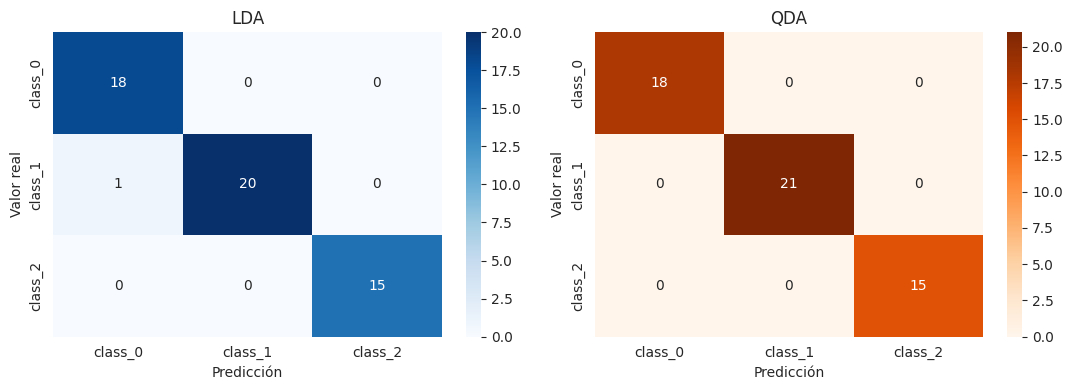

In [21]:
# Comparación visual de las matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm_lda, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=wine.target_names, yticklabels=wine.target_names)
axes[0].set_title("LDA")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor real")

sns.heatmap(cm_qda, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=wine.target_names, yticklabels=wine.target_names)
axes[1].set_title("QDA")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Valor real")

plt.tight_layout()
plt.show()

**Interpretación de la comparación:**

- **Desempeño predictivo:** ambos modelos alcanzan métricas muy altas sobre el Wine Dataset estandarizado, lo que confirma que las tres clases son fácilmente separables con las 13 variables químicas disponibles.
- **Matriz de confusión:** ambos modelos cometen pocos o ningún error de clasificación en el conjunto de prueba, sin un patrón claro de confusión entre clases específicas.
- **Tiempo de entrenamiento:** ambos modelos entrenan en fracciones de segundo dado el tamaño reducido del dataset (178 observaciones), por lo que la diferencia de tiempo no es un factor relevante aquí, aunque en datasets más grandes QDA tiende a ser más costoso por estimar una matriz de covarianza por clase.
- **Ventajas y limitaciones observadas:** LDA resulta preferible quirúrgicamente por su menor complejidad y su interpretabilidad, mientras que QDA sería más útil si las clases mostraran covarianzas claramente distintas, algo que no se observa de forma marcada en este dataset tras la estandarización.

## 8. Fronteras de decisión

Para visualizar las fronteras de decisión se seleccionan dos variables con alto poder discriminante (`flavanoids` y `color_intensity`) y se entrenan versiones de LDA y QDA usando solamente esas dos variables.

In [22]:
# Seleccionar dos variables para graficar las fronteras de decisión
variables_2d = ["flavanoids", "color_intensity"]
X_2d = df[variables_2d].values
y_2d = df["target"].values

# Estandarizar estas dos variables
escalador_2d = StandardScaler()
X_2d_esc = escalador_2d.fit_transform(X_2d)

# Entrenar LDA y QDA solo con estas dos variables (con todos los datos, para visualización)
lda_2d = LinearDiscriminantAnalysis().fit(X_2d_esc, y_2d)
qda_2d = QuadraticDiscriminantAnalysis().fit(X_2d_esc, y_2d)

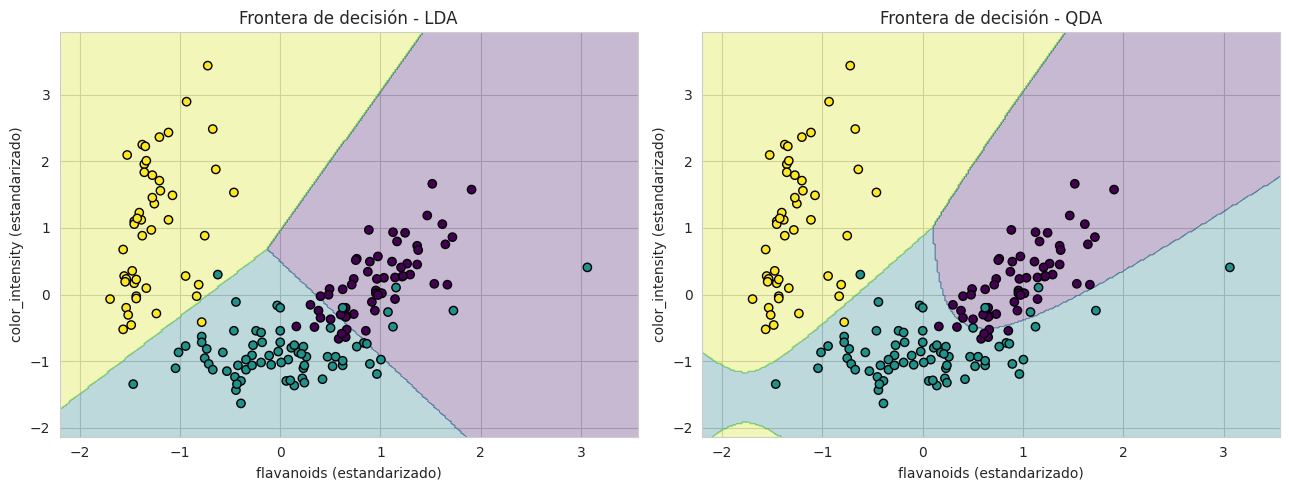

In [23]:
def graficar_frontera(modelo, X, y, titulo, ax):
    # Construir una malla de puntos que cubra el rango de las dos variables
    margen = 0.5
    x_min, x_max = X[:, 0].min() - margen, X[:, 0].max() + margen
    y_min, y_max = X[:, 1].min() - margen, X[:, 1].max() + margen
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))

    # Predecir la clase para cada punto de la malla
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k")
    ax.set_title(titulo)
    ax.set_xlabel("flavanoids (estandarizado)")
    ax.set_ylabel("color_intensity (estandarizado)")
    return scatter

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
graficar_frontera(lda_2d, X_2d_esc, y_2d, "Frontera de decisión - LDA", axes[0])
graficar_frontera(qda_2d, X_2d_esc, y_2d, "Frontera de decisión - QDA", axes[1])
plt.tight_layout()
plt.show()

**Análisis de las diferencias observadas:** en el gráfico de LDA las fronteras entre las tres regiones de color son líneas rectas, ya que el modelo asume una única matriz de covarianza compartida entre clases. En el gráfico de QDA las fronteras son curvas, lo que le permite ajustarse mejor a la forma real de cada agrupación cuando las clases no comparten exactamente la misma dispersión. En este par de variables de QDA le permite envolver de forma más ajustada a la clase central, aunque la diferencia práctica frente a LDA es moderada porque las tres nubes de puntos ya son bastante separables incluso con una frontera lineal.

## 9. Conclusiones

1. **Comportamiento de LDA:** LDA logró un desempeño muy alto sobre el Wine Dataset estandarizado, confirmando que su supuesto de covarianza compartida es una aproximación razonable para este conjunto de datos y que una frontera lineal es suficiente para separar las tres clases con muy pocos errores.

2. **Comportamiento de QDA:** QDA también alcanzó métricas muy altas y, al permitir una matriz de covarianza distinta por clase, generó fronteras de decisión curvas que se ajustan de forma más flexible a la distribución real de los datos, aunque en este caso particular la mejora frente a LDA fue marginal.

3. **Influencia de los supuestos estadísticos:** la cercanía en el desempeño de ambos modelos sugiere que las clases del Wine Dataset, tras estandarizar las variables, no presentan diferencias muy marcadas en sus matrices de covarianza, razón por la cual el supuesto de homocedasticidad de LDA no penaliza de forma importante su desempeño frente a QDA.

4. **Comparación de resultados:** las matrices de confusión y las métricas de accuracy, precisión, recall y F1-score de ambos modelos fueron muy similares, y el tiempo de entrenamiento de ambos fue prácticamente instantáneo dado el tamaño reducido del dataset, por lo que la elección entre ambos modelos dependería más de la interpretabilidad y la simplicidad que del desempeño puro.

5. **Aplicaciones prácticas:** en escenarios reales con datasets pequeños o con variables muy correlacionadas entre clases, como ocurre en este análisis químico de vinos, LDA representa una alternativa más simple, estable e interpretable; QDA, en cambio, sería más recomendable en problemas donde existe evidencia clara de que las clases tienen dispersiones muy distintas y se dispone de suficientes observaciones por clase para estimar cada matriz de covarianza de forma confiable.